preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/549 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

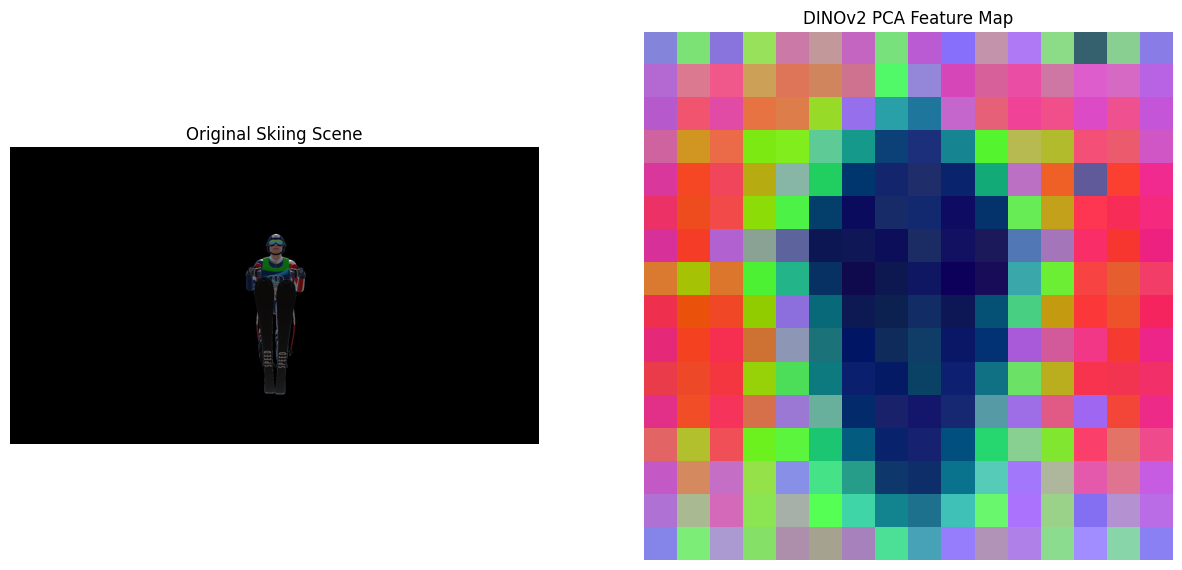

In [1]:
import torch
import torch.nn.functional as F
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# 1. 加载 DINOv2 模型 (推荐 large 版本，特征更细腻)
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-large')
model = AutoModel.from_pretrained('facebook/dinov2-large').to(device)

def check_ski_features(image_path):
    # 读取并预处理滑雪图像
    image = Image.open(image_path).convert('RGB')
    inputs = processor(images=image, return_tensors="pt").to(device)

    # 提取特征
    with torch.no_grad():
        outputs = model(**inputs)
        # 移除 CLS token，获取 patch 特征 [1, Num_Patches, 1024]
        features = outputs.last_hidden_state[:, 1:, :]

    # 计算 Patch 的网格尺寸
    h, w = inputs['pixel_values'].shape[-2:]
    ph, pw = h // 14, w // 14 
    features = features.reshape(ph * pw, -1).cpu().numpy()

    # 2. PCA 降维到 3 维 (对应 RGB)
    pca = PCA(n_components=3)
    pca_features = pca.fit_transform(features)

    # 归一化到 0-1 之间以便显示
    for i in range(3):
        pca_features[:, i] = (pca_features[:, i] - pca_features[:, i].min()) / \
                             (pca_features[:, i].max() - pca_features[:, i].min())

    # 重组为图像格式
    pca_img = pca_features.reshape(ph, pw, 3)
    
    # 3. 可视化对比
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.title("Original Skiing Scene")
    plt.imshow(image)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("DINOv2 PCA Feature Map")
    plt.imshow(pca_img) # 重点看滑雪板是什么颜色
    plt.axis('off')
    plt.show()

# 替换为你手头的滑雪视频截图
check_ski_features("/workspace/data/skiing_unity_dataset/data_pole_ski/female/Anim_Female_Skier_Braking/frames/capture_L0_A000/frame_000000.png")

In [3]:
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image

# 假设你已经定义了 model, processor, device
# 且 model 是用 ViT-L/14 训练的

# 1. 加载并预处理滑雪场景图像
img = Image.open("/workspace/data/skiing_unity_dataset/data_pole_ski/female/Anim_Female_Skier_Braking/frames/capture_L0_A000/frame_000000.png").convert('RGB') # 请确保替换为实际文件路径
inputs = processor(images=img, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)
    # 提取特征 [Batch, Num_Patches, 1024]
    features = outputs.last_hidden_state[:, 1:, :] 

# 计算特征图大小
h, w = inputs['pixel_values'].shape[-2:]
grid_h, grid_w = h // 14, w // 14

# ==========================================
# 2. 获取特征原型 (Prototype) - 关键步骤！
# ==========================================
# 方法 A：在 PCA 图上定位尖端点所在的 Patch 索引
# 假设你观察到 PCA 图第 20 行，第 15 列（坐标从 0 开始）是板子尖端
# 索引计算公式: idx = y * grid_width + x
target_y, target_x = 20, 15 # 这是基于上图观察得出的假设值
prototype_idx = target_y * grid_w + target_x
prototype_tip = features[0, prototype_idx, :].clone()

# ==========================================
# 3. 计算特征相似度图 (Cosine Similarity Map)
# ==========================================
# 计算整张图所有 Patch 特征与原型的余弦相似度
# 计算单位向量
last_hidden_states_norm = F.normalize(features, p=2, dim=-1)
prototype_tip_norm = F.normalize(prototype_tip, p=2, dim=-1)

# 计算相似度 [Batch, Num_Patches]
similarity_map = torch.mm(last_hidden_states_norm[0], prototype_tip_norm.unsqueeze(0).t()).squeeze()

# ==========================================
# 4. 可视化并定位最大值点
# ==========================================
# 将相似度图从 1D patches 还原回 2D 网格
sim_img = similarity_map.reshape(grid_h, grid_w).cpu().numpy()

# 寻找最大值点的坐标
# 注意：最大值点通常不是原原型点本身，而是其最鲁棒的几何位置
max_idx = torch.argmax(similarity_map)
pred_y, pred_x = max_idx // grid_w, max_idx % grid_w

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Scene")
plt.imshow(img)
plt.scatter(target_x*14, target_y*14, c='r', s=50, marker='+', label='Prototype') # 标记原型位置
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("DINOv2 Feature Similarity Map")
plt.imshow(sim_img, cmap='hot') # 越亮表示越相似，你应该能看到板尖位置最亮
plt.scatter(pred_x, pred_y, c='b', s=50, label='Predicted Point') # 标记预测位置
plt.axis('off')
plt.show()

print(f"滑雪板尖端的预测网格坐标: ({pred_x}, {pred_y})")

IndexError: index 335 is out of bounds for dimension 1 with size 256